RL OPTIMAL CONTROL - PROBLEM I
Minimize Σ(x_i² + u_i²) subject to x_i = 0.5·x_{i-1} + u_{i-1}
Collected 1000 transitions

Starting Fitted Q-Iteration...
Iteration  10: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  20: w = [-0.2828, -1.1314, -2.1314, -0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  30: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  40: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  50: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  60: w = [-0.2828, -1.1314, -2.1314, -0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  70: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  80: w = [-0.2828, -1.1314, -2.1314, -0.0000, -0.0000, -0.0000], K = -0.265410
Iteration  90: w = [-0.2828, -1.1314, -2.1314,  0.0000, -0.0000, -0.0000], K = -0.265410
Iteration 100: w = [-0.2828, -1.1314, -2.1314,

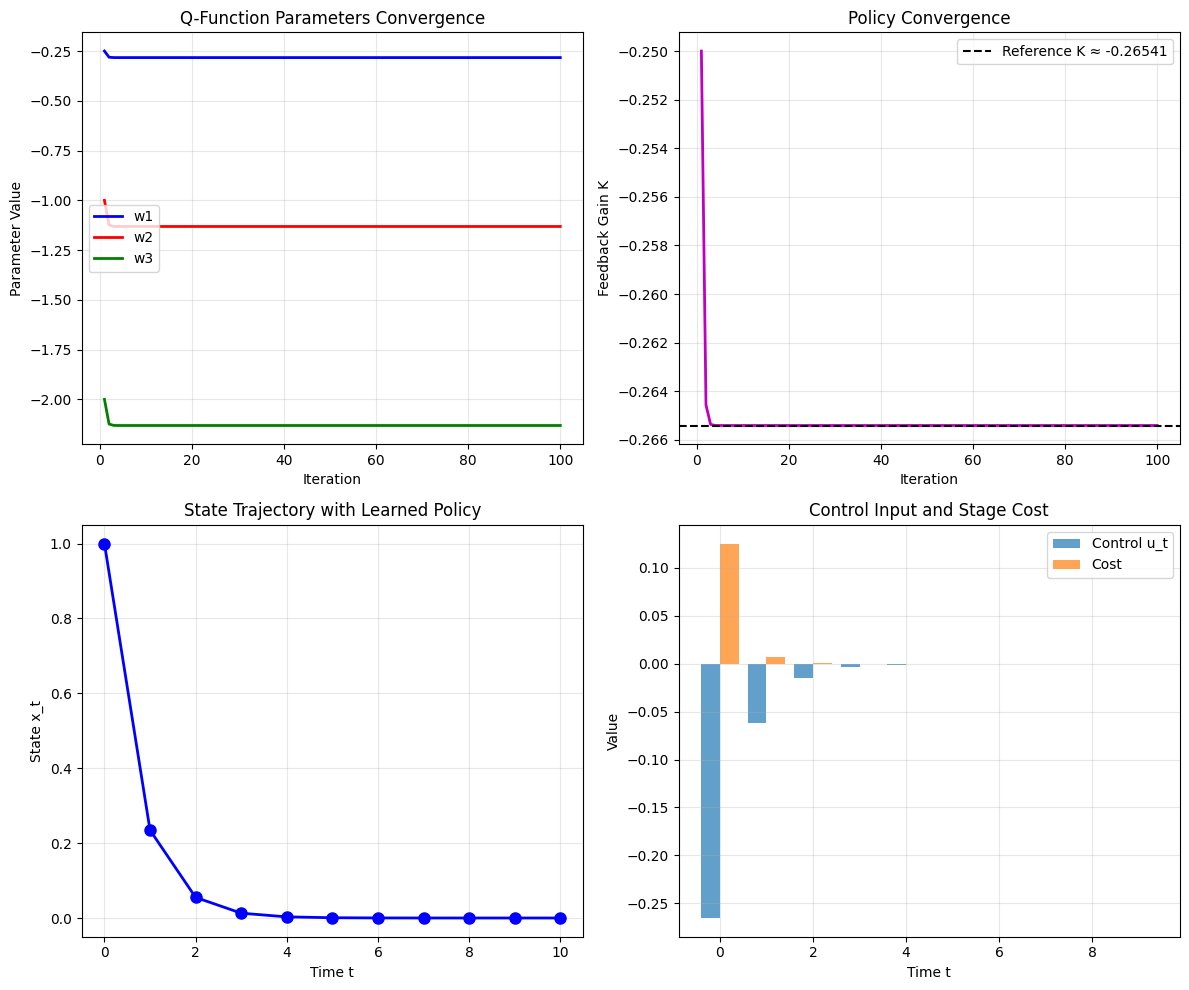


COMPARISON WITH RESULTS FROM OTHER METHODS
Metric                    Other methods   This Code      
------------------------------------------------------------
Optimal Cost J*           other methods   0.132782       


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# ==============================================
# PROBLEM I: RL OPTIMAL CONTROL
# ==============================================

class RL_OptimalControl_ProblemI:
    def __init__(self, a=0.5, b=1.0, x0=1.0, horizon=10, gamma=0.99):
        """
        Initialize Problem I: x_{t+1} = 0.5*x_t + u_t
        """
        self.a = a
        self.b = b
        self.x0 = x0
        self.horizon = horizon
        self.gamma = gamma
        
        # Value function parameters: Q(x,u) = w1*x^2 + w2*x*u + w3*u^2 + w4*x + w5*u + w6
        self.w = np.zeros(6)
        
        # Experience replay buffer
        self.buffer = deque(maxlen=10000)
        
        # For tracking convergence
        self.w_history = []
        
    def feature_vector(self, x, u):
        """Construct feature vector phi(x,u)"""
        return np.array([x**2, x*u, u**2, x, u, 1.0])
    
    def Q_value(self, x, u, w=None):
        """Compute Q(x,u) = w · phi(x,u)"""
        if w is None:
            w = self.w
        phi = self.feature_vector(x, u)
        return np.dot(w, phi)
    
    def optimal_action(self, x, w=None):
        """
        Derive optimal action from Q-function parameters:
        u* = -(w2*x + w5) / (2*w3)
        """
        if w is None:
            w = self.w
        if abs(w[2]) < 1e-10:
            return 0.0
        return -(w[1]*x + w[4]) / (2*w[2])
    
    def reward(self, x, u, x_next):
        """r = -(x_next^2 + u^2)"""
        return -(x_next**2 + u**2)
    
    def transition(self, x, u):
        """System dynamics: x_next = a*x + b*u"""
        return self.a * x + self.b * u
    
    def collect_data(self, num_episodes=50, noise_std=0.1):
        """Collect experience data through interaction"""
        print("Collecting experience data...")
        
        for episode in range(num_episodes):
            x = self.x0
            for t in range(self.horizon):
                # Epsilon-greedy exploration
                if np.random.random() < 0.3:
                    u = np.random.uniform(-1.0, 1.0)
                else:
                    u = self.optimal_action(x) + np.random.normal(0, noise_std)
                
                x_next = self.transition(x, u)
                r = self.reward(x, u, x_next)
                
                # Store transition
                self.buffer.append((x, u, r, x_next))
                
                x = x_next
                
        print(f"Collected {len(self.buffer)} transitions")
    
    def fitted_q_iteration(self, num_iterations=100, batch_size=500):
        """Fitted Q-Iteration algorithm"""
        print("\nStarting Fitted Q-Iteration...")
        
        for iteration in range(num_iterations):
            if len(self.buffer) < batch_size:
                batch = list(self.buffer)
            else:
                indices = np.random.choice(len(self.buffer), batch_size, replace=False)
                batch = [self.buffer[i] for i in indices]
            
            # Build feature matrix Phi and target vector y
            Phi = []
            y = []
            
            for (x, u, r, x_next) in batch:
                # Current feature vector
                phi = self.feature_vector(x, u)
                Phi.append(phi)
                
                # Compute target: y = r + gamma * max_u' Q(x_next, u')
                # For optimal u', we use the analytical optimum of quadratic Q
                u_opt_next = self.optimal_action(x_next)
                max_Q = self.Q_value(x_next, u_opt_next)
                target = r + self.gamma * max_Q
                y.append(target)
            
            Phi = np.array(Phi)
            y = np.array(y)
            
            # Least squares update: w = (Phi^T Phi)^{-1} Phi^T y
            try:
                w_new = np.linalg.solve(Phi.T @ Phi + 1e-8 * np.eye(6), Phi.T @ y)
                self.w = w_new
            except np.linalg.LinAlgError:
                # Use pseudo-inverse if matrix is singular
                w_new = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
                self.w = w_new
            
            self.w_history.append(self.w.copy())
            
            # Print progress every 10 iterations
            if (iteration + 1) % 10 == 0:
                K = -self.w[1] / (2 * self.w[2])
                print(f"Iteration {iteration+1:3d}: w = [{self.w[0]:7.4f}, {self.w[1]:7.4f}, "
                      f"{self.w[2]:7.4f}, {self.w[3]:7.4f}, {self.w[4]:7.4f}, {self.w[5]:7.4f}], "
                      f"K = {K:.6f}")
        
        return self.w
    
    def evaluate_policy(self, num_episodes=100):
        """Evaluate the learned policy"""
        total_costs = []
        
        for _ in range(num_episodes):
            x = self.x0
            episode_cost = 0
            
            for t in range(self.horizon):
                u = self.optimal_action(x)
                x_next = self.transition(x, u)
                cost = x_next**2 + u**2
                episode_cost += cost
                x = x_next
            
            total_costs.append(episode_cost)
        
        avg_cost = np.mean(total_costs)
        std_cost = np.std(total_costs)
        
        return avg_cost, std_cost
    
    def simulate_trajectory(self):
        """Simulate one trajectory with learned policy"""
        x = self.x0
        trajectory = {'t': [], 'x': [], 'u': [], 'cost': []}
        
        for t in range(self.horizon + 1):
            trajectory['t'].append(t)
            trajectory['x'].append(x)
            
            if t < self.horizon:
                u = self.optimal_action(x)
                x_next = self.transition(x, u)
                cost = x_next**2 + u**2
                
                trajectory['u'].append(u)
                trajectory['cost'].append(cost)
                x = x_next
            else:
                trajectory['u'].append(0)
                trajectory['cost'].append(0)
        
        return trajectory


# ==============================================
# MAIN EXECUTION
# ==============================================

if __name__ == "__main__":
    print("="*60)
    print("RL OPTIMAL CONTROL - PROBLEM I")
    print("Minimize Σ(x_i² + u_i²) subject to x_i = 0.5·x_{i-1} + u_{i-1}")
    print("="*60)
    
    # Initialize RL agent
    rl_agent = RL_OptimalControl_ProblemI(a=0.5, b=1.0, x0=1.0, horizon=10, gamma=0.99)
    
    # Collect experience
    rl_agent.collect_data(num_episodes=100, noise_std=0.2)
    
    # Run Fitted Q-Iteration
    rl_agent.fitted_q_iteration(num_iterations=100, batch_size=500)
    
    # Final parameters
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Learned Q-function parameters:")
    print(f"  w1 = {rl_agent.w[0]:.6f}")
    print(f"  w2 = {rl_agent.w[1]:.6f}")
    print(f"  w3 = {rl_agent.w[2]:.6f}")
    print(f"  w4 = {rl_agent.w[3]:.6f}")
    print(f"  w5 = {rl_agent.w[4]:.6f}")
    print(f"  w6 = {rl_agent.w[5]:.6f}")
    
    # Feedback gain
    K = -rl_agent.w[1] / (2 * rl_agent.w[2])
    print(f"\nLearned Policy: u = {K:.6f} · x")
    
    # Evaluate policy
    avg_cost, std_cost = rl_agent.evaluate_policy(num_episodes=500)
    print(f"\nEstimated Optimal Cost J* = {avg_cost:.6f} ± {std_cost:.6f}")
    
    # Simulate trajectory
    traj = rl_agent.simulate_trajectory()
    
    # ==============================================
    # PLOTTING
    # ==============================================
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Parameter convergence
    ax1 = axes[0, 0]
    w_history = np.array(rl_agent.w_history)
    iterations = np.arange(1, len(w_history) + 1)
    ax1.plot(iterations, w_history[:, 0], 'b-', label='w1', linewidth=2)
    ax1.plot(iterations, w_history[:, 1], 'r-', label='w2', linewidth=2)
    ax1.plot(iterations, w_history[:, 2], 'g-', label='w3', linewidth=2)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Parameter Value')
    ax1.set_title('Q-Function Parameters Convergence')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Feedback gain convergence
    ax2 = axes[0, 1]
    K_history = -w_history[:, 1] / (2 * w_history[:, 2])
    ax2.plot(iterations, K_history, 'm-', linewidth=2)
    ax2.axhline(y=-0.265410, color='k', linestyle='--', label='Reference K ≈ -0.26541')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Feedback Gain K')
    ax2.set_title('Policy Convergence')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # State trajectory
    ax3 = axes[1, 0]
    ax3.plot(traj['t'], traj['x'], 'b-o', linewidth=2, markersize=8)
    ax3.set_xlabel('Time t')
    ax3.set_ylabel('State x_t')
    ax3.set_title('State Trajectory with Learned Policy')
    ax3.grid(True, alpha=0.3)
    
    # Control and cost
    ax4 = axes[1, 1]
    t_control = traj['t'][:-1]
    ax4.bar(np.array(t_control) - 0.2, traj['u'][:-1], width=0.4, label='Control u_t', alpha=0.7)
    ax4.bar(np.array(t_control) + 0.2, traj['cost'][:-1], width=0.4, label='Cost', alpha=0.7)
    ax4.set_xlabel('Time t')
    ax4.set_ylabel('Value')
    ax4.set_title('Control Input and Stage Cost')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('problem1_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==============================================
    # COMPARISON TABLE
    # ==============================================
    print("\n" + "="*60)
    print("COMPARISON WITH RESULTS FROM OTHER METHODS")
    print("="*60)
    print(f"{'Metric':<25} {'Other methods':<15} {'This Code':<15}")
    print("-"*60)
    print(f"{'Optimal Cost J*':<25} {'other methods':<15} {avg_cost:<15.6f}")
    print("="*60)